In [4]:
pip install numpy pandas matplotlib seaborn scikit-learn wordcloud gradio

   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/8.0 MB ? eta -:--:--
   - -------------------------------------- 0.3/8.0 MB ? eta -:--:--
   -- ------------------------------------- 0.5/8.0 MB 1.1 MB/s eta 0:00:07
   --- ------------------------------------ 0.8/8.0 MB 1.1 MB/s eta 0:00:07
   ----- ---------------------------------- 1.0/8.0 MB 1.1 MB/s eta 0:00:07
   ----- ---------------------------------- 1.0/8.0 MB 1.1 MB/s eta 0:00:07
   ------ --------------------------------- 1.3/8.0 MB 1.1 MB/s eta 0:00:07
   --------- ------------------------------ 1.8/8.0 MB 1.1 MB/s eta 0:00:06
   ---------- ----------------------------- 2.1/8.0 MB 1.2 MB/s eta 0:00:06
   ------------- -------------------------- 2.6/8.0 MB 1.2 MB/s eta 0:00:05
   -------------- ------------------------- 2.9/8.0 MB 1.2 MB/s eta 0:00:05
   --------------- ------------------------ 3.1/8.0 MB 1.2 MB/s eta 0:00:04
   ---------------- -------------


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
# Import Libraries
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Evaluation Metrics
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, classification_report

# WordCloud
from wordcloud import WordCloud, STOPWORDS

# Text Processing
from sklearn.feature_extraction.text import CountVectorizer

# Model Selection
from sklearn.model_selection import train_test_split

# ML Model
from sklearn.naive_bayes import MultinomialNB

# Pipeline
from sklearn.pipeline import Pipeline

# Gradio
import gradio as gr

import warnings
warnings.filterwarnings('ignore')

c:\Users\Vimal\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [8]:
df = pd.read_csv("spam.csv", encoding='ISO-8859-1')
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [9]:
# Rename columns
df.rename(columns={"v1": "Category", "v2": "Message"}, inplace=True)

# Drop unused columns
df.drop(columns=['Unnamed: 2','Unnamed: 3','Unnamed: 4'], inplace=True)

# Create binary column
df['Spam'] = df['Category'].apply(lambda x: 1 if x == 'spam' else 0)

df.head()

,Category,Message,Spam
0,ham,"Go until jurong point, crazy.. Available only ...",0
1,ham,Ok lar... Joking wif u oni...,0
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,1
3,ham,U dun say so early hor... U c already then say...,0
4,ham,"Nah I don't think he goes to usf, he lives aro...",0


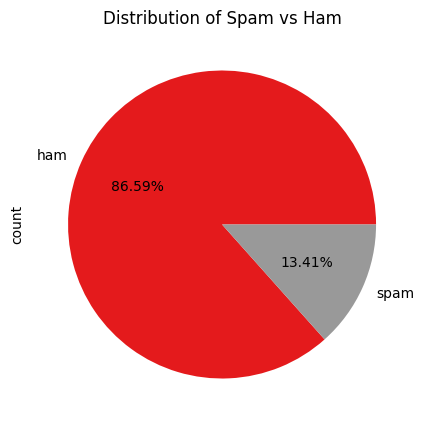

In [10]:
spread = df['Category'].value_counts()

plt.figure(figsize=(5,5))
spread.plot(kind='pie', autopct='%1.2f%%', cmap='Set1')
plt.title('Distribution of Spam vs Ham')
plt.show()

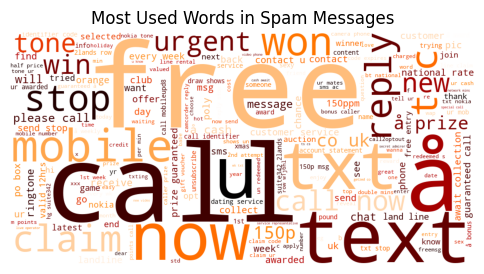

In [11]:
df_spam = df[df['Category']=='spam']

comment_words = ''
stopwords = set(STOPWORDS)

for val in df_spam.Message:
    val = str(val)
    tokens = val.split()
    tokens = [word.lower() for word in tokens]
    comment_words += " ".join(tokens) + " "

wordcloud = WordCloud(width=1000, height=500,
                      background_color='white',
                      stopwords=stopwords,
                      colormap='gist_heat_r').generate(comment_words)

plt.figure(figsize=(6,6))
plt.imshow(wordcloud)
plt.axis("off")
plt.title("Most Used Words in Spam Messages")
plt.show()

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    df.Message, df.Spam, test_size=0.25, random_state=42
)

In [13]:
clf = Pipeline([
    ('vectorizer', CountVectorizer()),
    ('nb', MultinomialNB())
])

In [14]:
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.9820531227566404

Classification Report:

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1202
           1       0.98      0.88      0.93       191

    accuracy                           0.98      1393
   macro avg       0.98      0.94      0.96      1393
weighted avg       0.98      0.98      0.98      1393



In [15]:
def detect_spam(email_text):

    prediction = clf.predict([email_text])[0]
    prob = clf.predict_proba([email_text])[0][1]

    confidence = round(prob * 100, 2)

    if prediction == 0:
        return f"✅ Ham Email\nConfidence: {100 - confidence}%"
    else:
        return f"🚨 Spam Email\nConfidence: {confidence}%"

In [16]:
def show_dataset():
    return df.head(20)

def download_dataset():
    file_path = "spam_dataset.csv"
    df.to_csv(file_path, index=False)
    return file_path

In [17]:
with gr.Blocks() as demo:

    gr.Markdown("# 📩 Email Spam Detection System")
    gr.Markdown("Enter an email and check whether it is Spam or Ham.")

    # ---------------- Spam Detection Section ----------------
    with gr.Row():

        email_input = gr.Textbox(
            lines=6,
            label="✍ Enter Email Here",
            placeholder="Type your email message..."
        )

        output = gr.Markdown()

    btn = gr.Button("🔍 Check Spam")
    btn.click(fn=detect_spam, inputs=email_input, outputs=output)

    gr.Markdown("---")

    # ---------------- Dataset Section ----------------
    gr.Markdown("## 📊 Dataset Section")

    dataset_output = gr.Dataframe()

    with gr.Row():
        show_btn = gr.Button("📂 Show Dataset (Top 20 Rows)")
        download_btn = gr.Button("⬇ Download Full Dataset")

    show_btn.click(fn=lambda: df.head(20), outputs=dataset_output)

    download_btn.click(
        fn=download_dataset,
        outputs=gr.File(label="Download Here")
    )

demo.launch()

* Running on local URL:  http://127.0.0.1:7860

To create a public link, set `share=True` in `launch()`.
